In [1]:
import pandas as pd
import numpy as np 

data = {
    "name" : ["alice", "bob", "alice", "charlie", "bob", "david"],
    "age" :   ["25", "30", "25", "35", "30", "40"],
    "salary" : [50000, 60000, 50000, 70000, 60000, 80000,],
    "city" :  ["NY", "LA", "NY", "SF", "LA", "NY"]

}
df=pd.DataFrame(data)
print("original data:")
print(df)

original data:
      name age  salary city
0    alice  25   50000   NY
1      bob  30   60000   LA
2    alice  25   50000   NY
3  charlie  35   70000   SF
4      bob  30   60000   LA
5    david  40   80000   NY


In [3]:
df_no_duplicates = df.drop_duplicates()
print("\nDataset after removing duplicate rows:")
print(df_no_duplicates)


Dataset after removing duplicate rows:
      name age  salary city
0    alice  25   50000   NY
1      bob  30   60000   LA
3  charlie  35   70000   SF
5    david  40   80000   NY


In [4]:
df_no_duplicates_subset = df.drop_duplicates(subset=["name", "age"])
print("\nDataset after removing duplicates based on 'name' and 'age':")
print(df_no_duplicates_subset)


Dataset after removing duplicates based on 'name' and 'age':
      name age  salary city
0    alice  25   50000   NY
1      bob  30   60000   LA
3  charlie  35   70000   SF
5    david  40   80000   NY


In [5]:
df["Adjusted_Salary"] = df["salary"].apply(lambda x: x * 1.1)#add a new column for adjusted salary and 10% increment
print("\nDataset after applying a function to transform 'salary':")
print(df)


Dataset after applying a function to transform 'salary':
      name age  salary city  Adjusted_Salary
0    alice  25   50000   NY          55000.0
1      bob  30   60000   LA          66000.0
2    alice  25   50000   NY          55000.0
3  charlie  35   70000   SF          77000.0
4      bob  30   60000   LA          66000.0
5    david  40   80000   NY          88000.0


In [6]:
#data transformaation using mapping
import pandas as pd
import numpy as np 

data = {
    "name" : ["alice", "bob", "alice", "charlie", "bob", "david"],
    "age" :   ["25", "30", "25", "35", "30", "40"],
    "salary" : [50000, 60000, 50000, 70000, 60000, 80000,],
    "city" :  ["NY", "LA", "NY", "SF", "LA", "NY"]

}
df=pd.DataFrame(data)
print("original data:")
print(df)
city_to_region= {"NY": "East", "LA":"West","SF":"West"}
df["region"] = df["city"].map(city_to_region)
print("\n dataset after mapping city to region")
print(df)

original data:
      name age  salary city
0    alice  25   50000   NY
1      bob  30   60000   LA
2    alice  25   50000   NY
3  charlie  35   70000   SF
4      bob  30   60000   LA
5    david  40   80000   NY

 dataset after mapping city to region
      name age  salary city region
0    alice  25   50000   NY   East
1      bob  30   60000   LA   West
2    alice  25   50000   NY   East
3  charlie  35   70000   SF   West
4      bob  30   60000   LA   West
5    david  40   80000   NY   East


In [8]:
#normalization means that take any type of data in a specific range (min - max scaling = x-xmin/xmax-xmin)
## Normalization: scale values between 0 and 1
df["age"] = pd.to_numeric(df["age"])
df["salary"] = pd.to_numeric(df["salary"])

df["Normalized_age"] = (df["age"] - df["age"].min()) / (df["age"].max() - df["age"].min())

df["Normalized_salary"] = (df["salary"] - df["salary"].min()) / (df["salary"].max() - df["salary"].min())

print(df)

      name  age  salary city region  Normalized_age  Normalized_salary
0    alice   25   50000   NY   East        0.000000           0.000000
1      bob   30   60000   LA   West        0.333333           0.333333
2    alice   25   50000   NY   East        0.000000           0.000000
3  charlie   35   70000   SF   West        0.666667           0.666667
4      bob   30   60000   LA   West        0.333333           0.333333
5    david   40   80000   NY   East        1.000000           1.000000


In [10]:
import pandas as pd
import numpy as np
#Createasampledataset
data= {"Value":[10, 12,14,15,100, 20, 18, 19, 22]}
df =pd.DataFrame(data)
print("mean= ",df["Value"].mean())
print("Standad deviation=",df["Value"].std())
#Calculate Z-Score
df["Z_Score"] =(df["Value"]-df["Value"].mean())/df["Value"].std()
print("Z_Score is",df["Z_Score"])
#Filteroutliers(threshold:|Z|23)
filtered_df= df[np.abs(df["Z_Score"]) <=2]
print("Dataset afterfilteringoutliersusingZ-Score:")
print(filtered_df)

mean=  25.555555555555557
Standad deviation= 28.1873691177055
Z_Score is 0   -0.551863
1   -0.480909
2   -0.409955
3   -0.374478
4    2.641057
5   -0.197094
6   -0.268048
7   -0.232571
8   -0.126140
Name: Z_Score, dtype: float64
Dataset afterfilteringoutliersusingZ-Score:
   Value   Z_Score
0     10 -0.551863
1     12 -0.480909
2     14 -0.409955
3     15 -0.374478
5     20 -0.197094
6     18 -0.268048
7     19 -0.232571
8     22 -0.126140


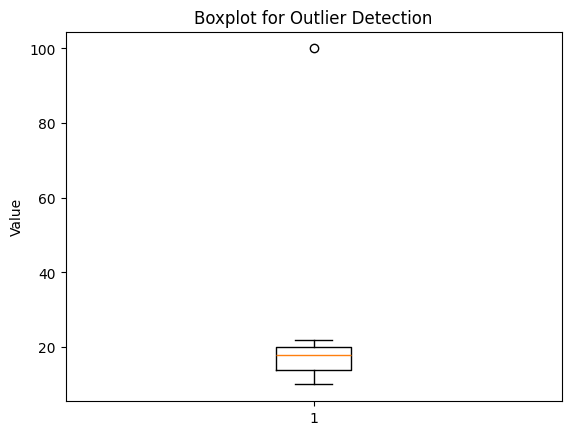

In [11]:
import matplotlib.pyplot as plt
plt.boxplot(df["Value"])
plt.title("Boxplot for Outlier Detection")
plt.ylabel("Value")
plt.show()

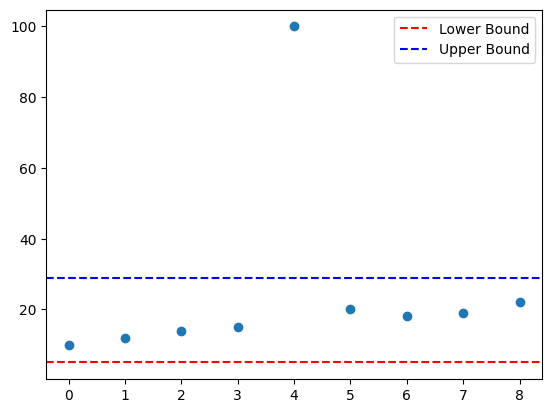

In [13]:

Q1 = df["Value"].quantile(0.25)
Q3 = df["Value"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plt.scatter(range(len(df)), df["Value"])
plt.axhline(lower_bound, color="red", linestyle="--", label="Lower Bound")
plt.axhline(upper_bound, color="blue", linestyle="--", label="Upper Bound")
plt.legend()
plt.show()